In [1]:
import pandas as pd
import numpy as np
import sys
from contextlib import redirect_stdout

from ml_pipeline.subpopulation import run_pipeline, run_model_error_analysis
from ml_evaluation.error_analysis import comprehensive_error_analysis, analyze_feature_contribution_to_errors, create_error_visualization

import warnings
warnings.filterwarnings('ignore')

/home/valeriya/project/homeserve/credit_policy/.direnv/python-3.12.0/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.2) or chardet (7.2.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


In [2]:
# FILTER TO HIGH ENGAGEMENT CUSTOMERS (3+ quotes)
print("\n🎯 FILTERING TO HIGH ENGAGEMENT CUSTOMERS (3+ quotes)")
print("="*80)

# Load data
df_quotes = pd.read_csv('cleaned_quote_data.csv')
df_quotes['dt_creation_devis'] = pd.to_datetime(df_quotes['dt_creation_devis'])

# Count quotes per customer
quote_counts = df_quotes.groupby('numero_compte').size().reset_index(name='quote_count')

# Get customers with 3+ quotes
high_engagement_ids = quote_counts[quote_counts['quote_count'] >= 3]['numero_compte'].tolist()

# Filter data
df_quotes_high_eng = df_quotes[df_quotes['numero_compte'].isin(high_engagement_ids)].copy()

print(f"Original customers: {df_quotes['numero_compte'].nunique():,}")
print(f"High engagement customers (3+ quotes): {len(high_engagement_ids):,}")
print(f"Quotes: {len(df_quotes_high_eng):,}")

# Save to file
df_quotes_high_eng.to_csv('cleaned_quote_data_high_eng.csv', index=False)
print(f"\n✅ Saved to cleaned_quote_data_high_eng.csv")


🎯 FILTERING TO HIGH ENGAGEMENT CUSTOMERS (3+ quotes)
Original customers: 25,716
High engagement customers (3+ quotes): 2,127
Quotes: 7,688

✅ Saved to cleaned_quote_data_high_eng.csv


In [3]:
df_quotes = pd.read_csv('cleaned_quote_data_high_eng.csv')


📊 Original quote data: 7,688 quotes from 2,127 customers

🏗️  BUILDING FEATURES FOR SUBPOPULATION CUSTOMERS
Creating OPTIMIZED customer features (mode: first_conversion)...
  Filtering post-first-purchase data...
  Customers: 2,127, Quotes: 6,988
  Calculating features...
  Calculating price trajectory (optimized)...
✓ Created 14 leakage-free features
→ 2,127 customers | 52.0% converters
⏱️  Execution time: 1.0 seconds
✅ SUCCESS! Achieved ≤ 3s target
CREATING FIRST CONVERSION PREDICTION FEATURES (LEAKAGE-FREE)
  Total customers: 2,127
⚡ Processing customers with corrected first-conversion logic...
  Processed 0/2,127 customers
✅ First-conversion features calculation complete

🔍 VALIDATION REPORT:
   Total customers: 2,127
   First converters: 1,106 (52.0%)
   Never converters: 1,021

📊 Distribution check:
   Converters with 0 historical quotes: 366
   Non-converters with 0 historical quotes: 0
   Avg historical quotes - Converters: 1.4
   Avg historical quotes - Non-converters: 2.5

✅

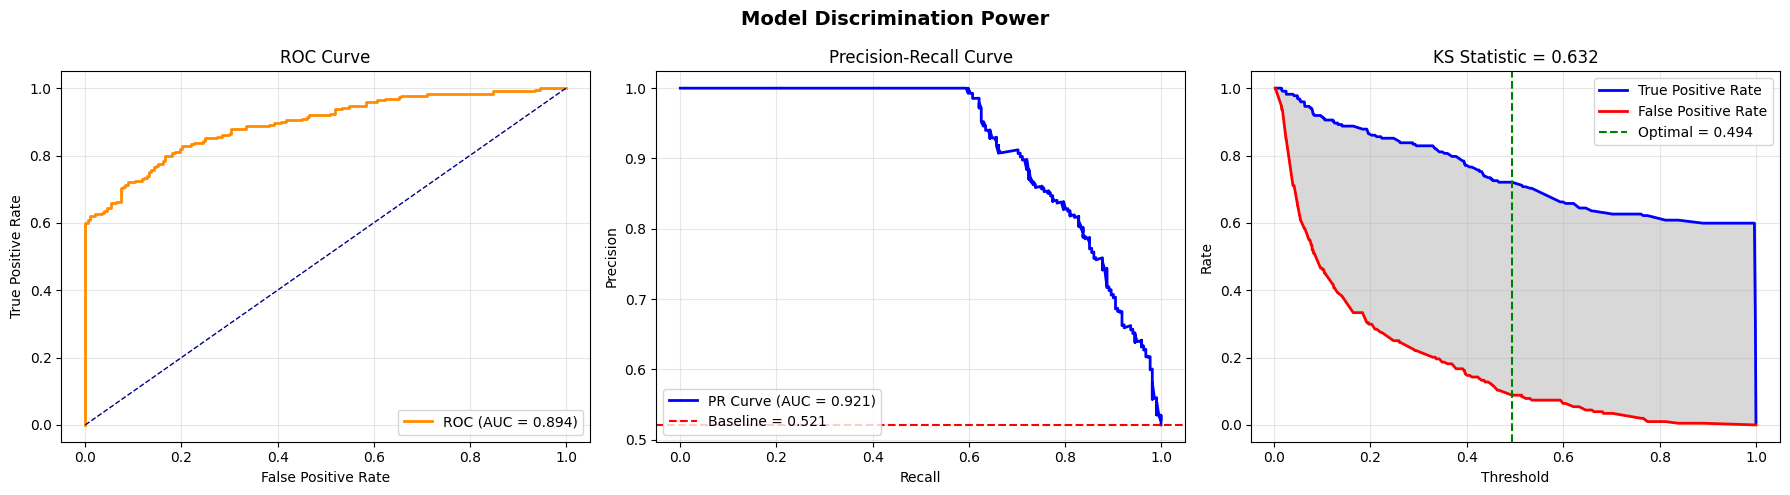

• ROC-AUC: 0.8940
• PR-AUC: 0.9214
• KS Statistic: 0.632 (OUTSTANDING discrimination)
• Optimal Threshold: 0.494

💼 STEP 2: BUSINESS IMPACT
----------------------------------------
Verification of decile assignment:
Decile 1 mean prob: 0.999
Decile 10 mean prob: 0.020


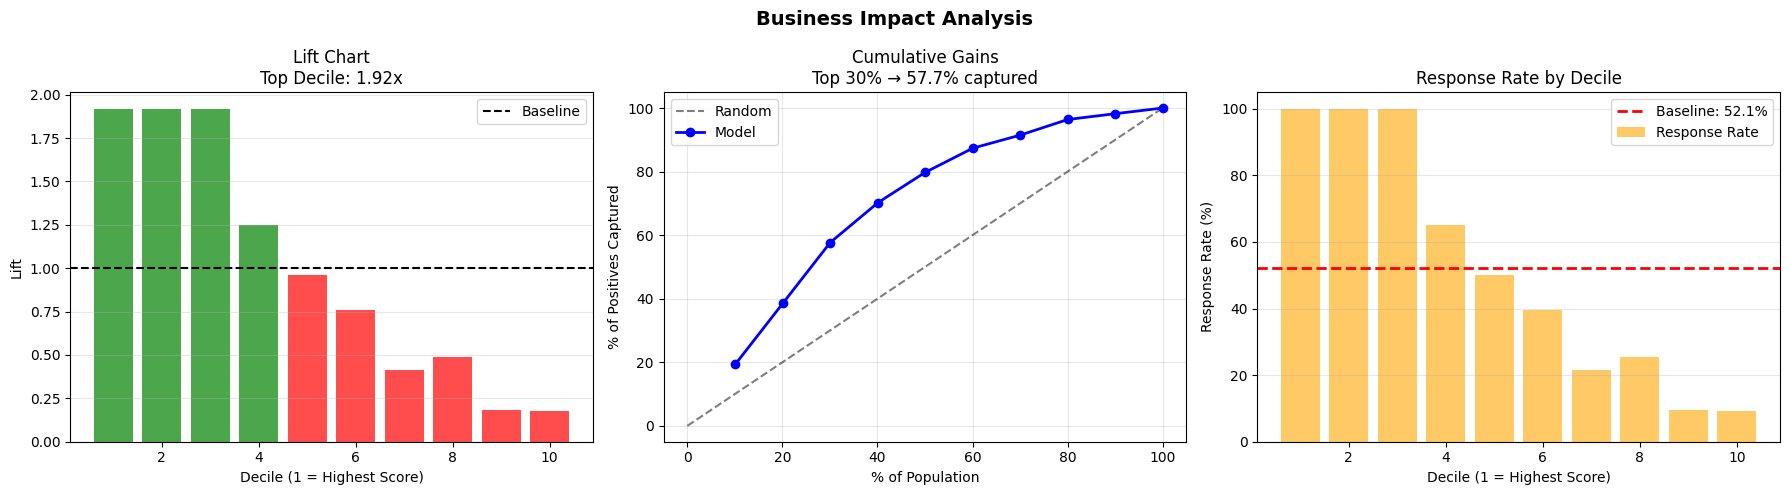

• Top Decile Lift: 0.18x
• Top 30% captures: 57.7% of positives
• Baseline response rate: 52.1%
• Top decile response: 100.0%

📈 STEP 4: CONFUSION MATRIX
----------------------------------------


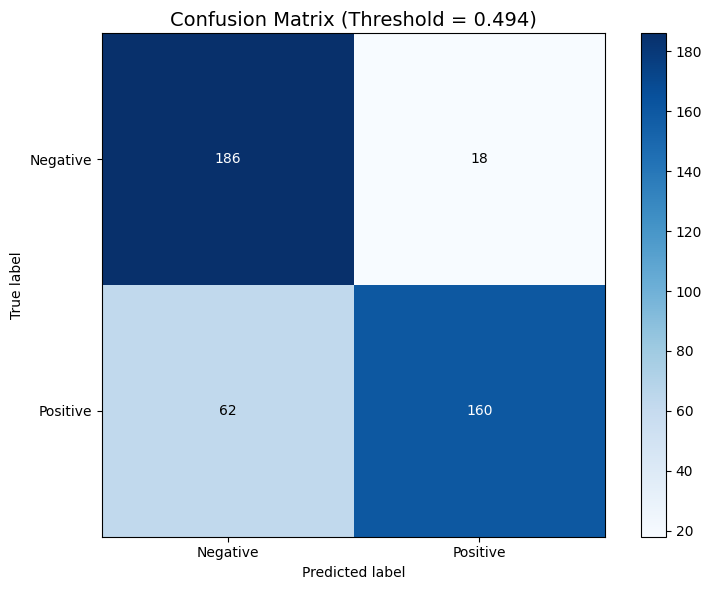

At threshold 0.494:
• Accuracy: 0.812
• Precision: 0.899
• Recall: 0.721
• F1-Score: 0.800
• True Positives: 160
• False Positives: 18
• True Negatives: 186
• False Negatives: 62

FINAL VALIDATION SUMMARY

✅ DISCRIMINATION POWER:
   KS Statistic: 0.632 (OUTSTANDING discrimination)

✅ BUSINESS VALUE:
   Efficiency: 0.18x better than random
   Coverage: Top 30% → 57.7% captured

✅ MODEL QUALITY:
   ROC-AUC: 0.8940 (Excellent if >0.8)
   PR-AUC: 0.9214 (Excellent if >0.7)

✅ OPERATIONAL METRICS:
   Optimal Threshold: 0.494
   Precision at threshold: 0.899
   Recall at threshold: 0.721

🔍 FEATURE IMPORTANCE - SUBPOPULATION MODEL

Top 20 Features:
                         feature  importance
176      quote_consistency_score    0.148096
98       avg_days_between_quotes    0.064395
249     max_price_over_min_price    0.023008
36           model_variety_score    0.015104
178    decision_efficiency_score    0.014530
153           engagement_density    0.012954
54               first_equipment  

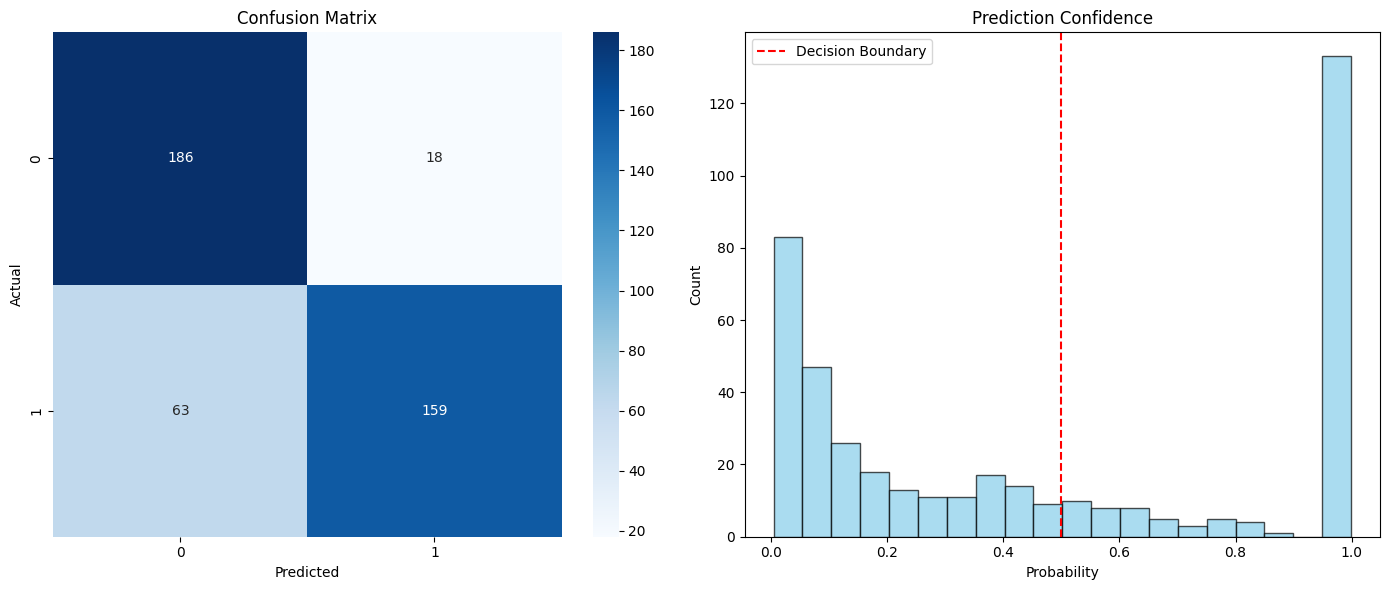

In [4]:
#with redirect_stdout(open('/dev/null', 'w')):
result = run_pipeline(df_quotes)

run_model_error_analysis(result['X_test'], result['y_test'], result['model'])